# HyperSense — Model Explainability with SHAP

## Overview

This notebook performs post-hoc explainability analysis on the final selected HyperSense hypertension prediction model. The tuned XGBoost model developed in `04_modeling.ipynb` is interpreted using SHAP (SHapley Additive exPlanations) to understand how individual predictors contribute to hypertension risk predictions.

## Objectives

- Generate global feature importance rankings
- Visualize feature effects across the test population
- Explain individual patient-level predictions
- Identify key drivers of hypertension risk
- Produce explainability outputs for deployment and competition presentation

## Final Model

Model: Tuned XGBoost

Predictors:
- Age
- Gender
- Residence
- Educational Level
- Tobacco Use

Target:
- Hypertension Status (0 = Non-hypertensive, 1 = Hypertensive)

The outputs from this notebook will support both model transparency and integration into the HyperSense screening application.

In [1]:
# Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)

In [25]:
# Load modelling dataset

model_df = pd.read_csv(
    "../outputs/hypersense_model_ready.csv"
)

print(model_df.shape)
model_df.head()

(20446, 9)


,caseid,country,sample_weight,age,gender,residence,educational_level,tobacco_use,htn_status
0,1 1 1,Ghana,856663.0,50.0,1,0,2,0,1.0
1,1 3 1,Ghana,856663.0,27.0,1,0,2,0,0.0
2,1 6 1,Ghana,856663.0,24.0,1,0,2,0,0.0
3,111 1,Ghana,856663.0,40.0,1,0,1,1,0.0
4,119 1,Ghana,856663.0,43.0,1,0,2,0,0.0


In [26]:
# Feature matrix and target

X = model_df[
    [
        "age",
        "gender",
        "residence",
        "educational_level",
        "tobacco_use"
    ]
]

y = model_df["htn_status"]

weights = model_df["sample_weight"]

model_df["stratify_key"] = (
    model_df["country"]
    + "_"
    + model_df["htn_status"].astype(str)
)
model_df

,caseid,country,sample_weight,age,gender,residence,educational_level,tobacco_use,htn_status,stratify_key
0,1 1 1,Ghana,856663.0,50.0,1,0,2,0,1.0,Ghana_1.0
1,1 3 1,Ghana,856663.0,27.0,1,0,2,0,0.0,Ghana_0.0
2,1 6 1,Ghana,856663.0,24.0,1,0,2,0,0.0,Ghana_0.0
3,111 1,Ghana,856663.0,40.0,1,0,1,1,0.0,Ghana_0.0
4,119 1,Ghana,856663.0,43.0,1,0,2,0,0.0,Ghana_0.0
...,...,...,...,...,...,...,...,...,...,...
20441,555 104 1,Benin,749215.0,39.0,0,1,0,0,1.0,Benin_1.0
20442,555 118 1,Benin,749215.0,39.0,0,1,0,0,0.0,Benin_0.0
20443,555 132 1,Benin,749215.0,48.0,0,1,0,0,0.0,Benin_0.0
20444,555 147 2,Benin,749215.0,30.0,0,1,2,0,0.0,Benin_0.0


In [8]:
# Recreate modelling split

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X,
    y,
    weights,
    test_size=0.20,
    random_state=99,
    stratify=model_df["stratify_key"]
)

In [7]:
# Load final tuned XGBoost model

best_xgb = joblib.load(
    "../outputs/final_xgb_model.pkl"
)

In [9]:
# ==================================================
# Initialize SHAP explainer
# ==================================================

explainer = shap.TreeExplainer(
    best_xgb
)

shap_values = explainer.shap_values(
    X_test
)

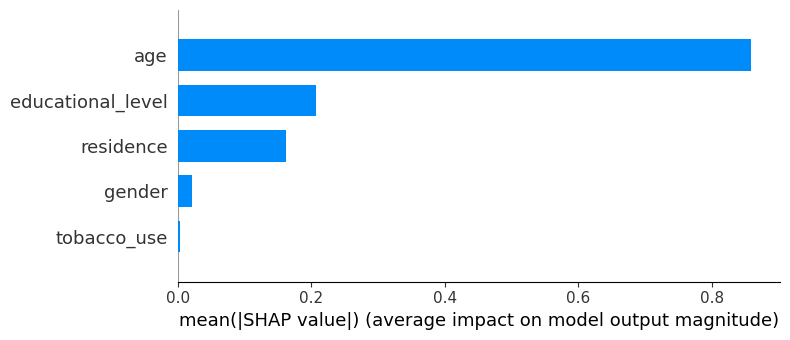

In [15]:
# ==================================================
# Global SHAP feature importance
# ==================================================

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "../outputs/shap_global_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

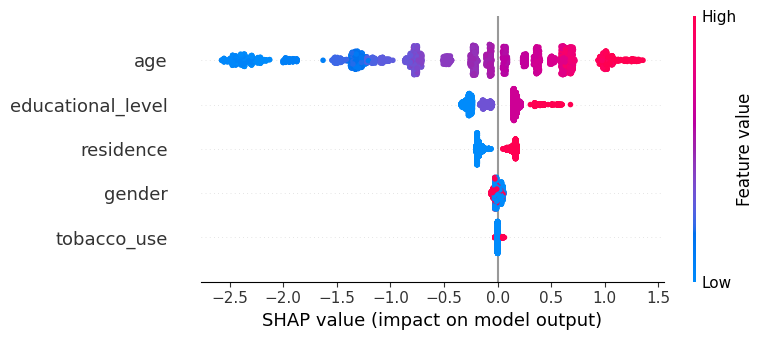

In [16]:
# ==================================================
# SHAP beeswarm plot
# ==================================================

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../outputs/shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# ==================================================
# Single prediction explanation
# ==================================================

sample_idx = 0
sample = X_test.iloc[[sample_idx]]
sample

,age,gender,residence,educational_level,tobacco_use
12680,42.0,0,1,3,0


In [29]:
# ==================================================
# SHAP values for selected respondent
# ==================================================

sample_shap = explainer(
    sample
)
sample_shap

.values =
array([[ 6.2044454e-01,  1.2135110e-02,  1.0002905e-01,  3.6849439e-01,
        -4.4457387e-04]], dtype=float32)

.base_values =
array([-0.36664584], dtype=float32)

.data =
array([[42.,  0.,  1.,  3.,  0.]])

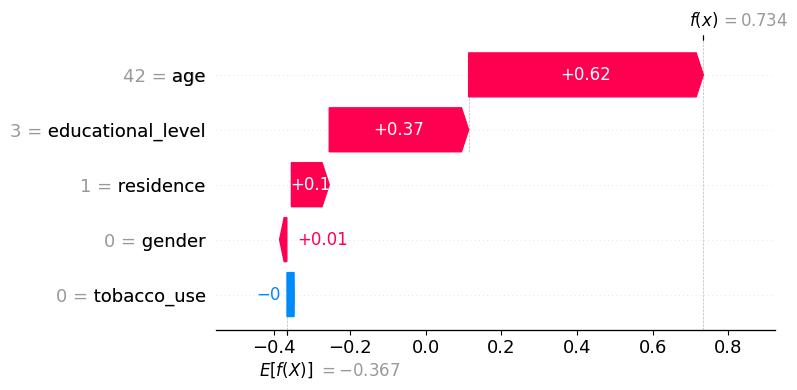

In [19]:
# ==================================================
# Waterfall explanation
# ==================================================

shap.plots.waterfall(
    sample_shap[0],
    show=False
)

plt.tight_layout()

plt.savefig(
    "../outputs/shap_waterfall_example.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# ==================================================
# Highest-risk respondent
# ==================================================

risk_probabilities = best_xgb.predict_proba(
    X_test
)[:, 1]

highest_risk_idx = np.argmax(
    risk_probabilities
)

print(
    f"Predicted Risk: {risk_probabilities[highest_risk_idx]:.3f}"
)

X_test.iloc[[highest_risk_idx]]

Predicted Risk: 0.813


,age,gender,residence,educational_level,tobacco_use
3376,58.0,1,0,3,0


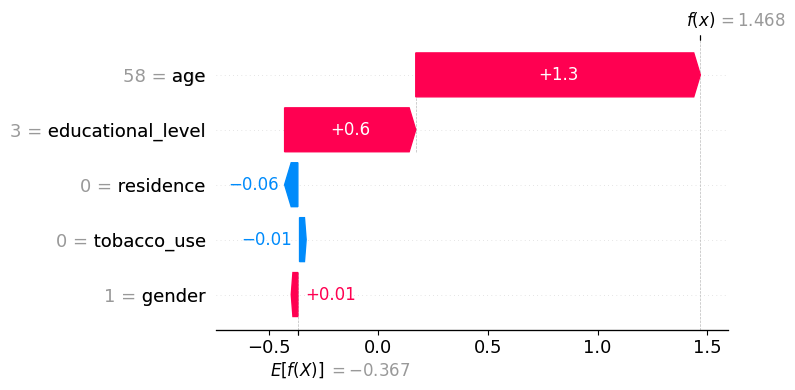

In [21]:
# ==================================================
# Explain highest-risk respondent
# ==================================================

high_risk_sample = X_test.iloc[
    [highest_risk_idx]
]

high_risk_shap = explainer(
    high_risk_sample
)

shap.plots.waterfall(
    high_risk_shap[0],
    show=False
)

plt.tight_layout()

plt.savefig(
    "../outputs/shap_high_risk_example.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
# ==================================================
# Mean absolute SHAP values
# ==================================================

shap_importance = pd.DataFrame(
    {
        "feature": X_test.columns,
        "mean_abs_shap":
        np.abs(shap_values).mean(axis=0)
    }
)

shap_importance = (
    shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance

,feature,mean_abs_shap
0,age,0.858829
1,educational_level,0.207929
2,residence,0.161859
3,gender,0.022156
4,tobacco_use,0.004062


### Explainability Summary

SHAP analysis demonstrated that age was the strongest contributor to hypertension risk predictions, followed by educational level, residence, gender and tobacco use.

The observed feature importance pattern aligns with established epidemiological evidence regarding hypertension risk factors and supports the clinical plausibility of the HyperSense model.

The explainability framework enables both population-level interpretation and patient-level decision support, providing transparent justification for individual risk predictions generated by the HyperSense platform.